# Plant Disease Classification

**Automated identification of plant diseases from leaf images using deep learning.**

This notebook covers the full pipeline:
1. **Environment Setup** Clone the repository and install dependencies
2. **Kaggle API Configuration** Authenticate and configure dataset access
3. **Dataset Preparation** Download, extract, and organize the dataset
4. **Exploratory Data Analysis** Visualize class distributions and dataset statistics
5. **Model Training** Train and compare ResNet-18, ResNet-50, and EfficientNet-B0
6. **Inference** Run predictions on the held-out test set

## 1. Environment Setup

Clone the project repository and install all required Python packages.

In [1]:
# Clone the project repository
!git clone https://github.com/StefaNNN772/PlantDiseasesPrediction
%cd PlantDiseasesPrediction

Cloning into 'PlantDiseasesPrediction'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 53 (delta 18), reused 48 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 16.04 KiB | 5.35 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/PlantDiseasesPrediction


In [2]:
# Install all required packages
!pip install -q torch torchvision albumentations Pillow numpy pandas \
    matplotlib seaborn scikit-learn PyYAML tqdm opencv-python kaggle

## 2. Kaggle API Configuration

Upload your `kaggle.json` credentials file and configure the Kaggle CLI for dataset downloads.

In [3]:
# Upload kaggle.json credentials
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "stefanlazarevic02",\r\n  "key": "KGAT_a86d048c2a6fe11726b46fb124b435b2"\r\n}'}

In [4]:
# Set up Kaggle credentials directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 3. Dataset Download & Preparation

Download the [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset) from Kaggle, extract it, and reorganize the test split into the correct directory structure.

In [5]:
# Download and extract the dataset
!kaggle datasets download -d 'vipoooool/new-plant-diseases-dataset'
!unzip -q new-plant-diseases-dataset.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.69G/2.70G [00:24<00:00, 154MB/s]
100% 2.70G/2.70G [00:24<00:00, 116MB/s]


In [6]:
# Reorganize directory structure: move test split and clean up duplicates
%cd data
!rm -rf "new plant diseases dataset(augmented)"
!mv "test/test" "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/"
!rm -rf "test"
%cd ..

/content/PlantDiseasesPrediction/data
/content/PlantDiseasesPrediction


## 4. Exploratory Data Analysis

Examine the dataset structure, class distribution, and basic statistics before training.

NEW PLANT DISEASES DATASET - ANALYSIS

TRAIN SET:
Classes: 38
Total images: 70,295
Min per class: 1,642
Max per class: 2,022
Mean per class: 1850
Std per class: 106

VALID SET:
Classes: 38
Total images: 17,572
Min per class: 410
Max per class: 505
Mean per class: 462
Std per class: 26
PLANT SPECIES (14):
   Apple                               | 4 classes | 3 diseases | 7,771 images
   Blueberry                           | 1 classes | 0 diseases | 1,816 images
   Cherry (including sour)             | 2 classes | 1 diseases | 3,509 images
   Corn (maize)                        | 4 classes | 3 diseases | 7,316 images
   Grape                               | 4 classes | 3 diseases | 7,222 images
   Orange                              | 1 classes | 1 diseases | 2,010 images
   Peach                               | 2 classes | 1 diseases | 3,566 images
   Pepper, bell                        | 2 classes | 1 diseases | 3,901 images
   Potato                              | 3 classes | 2 disease

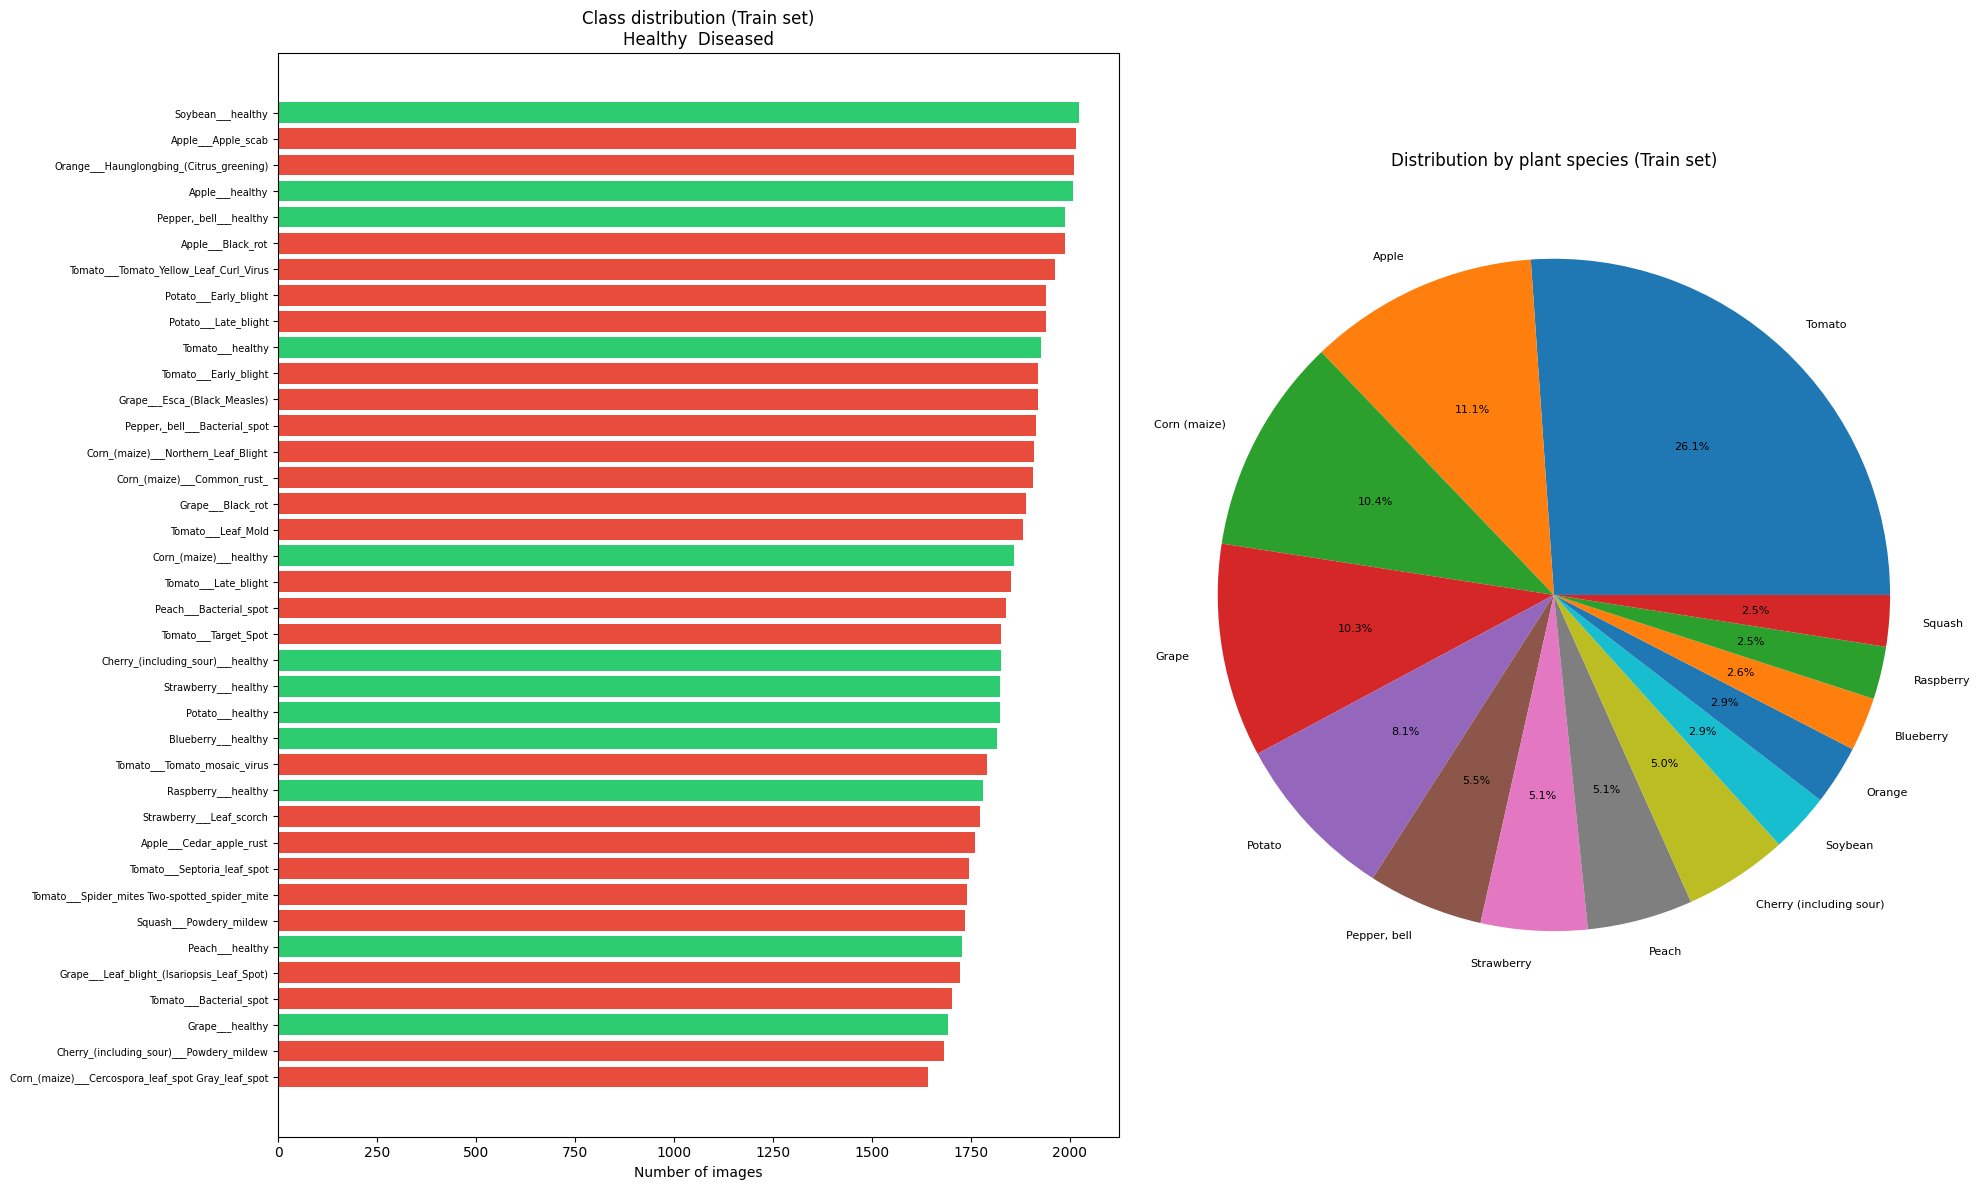

In [7]:
import yaml
from src.preprocessing.dataset_analyzer import DatasetAnalyzer

# Load configuration
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Initialize dataset analyzer
analyzer = DatasetAnalyzer(
    root_dir=config["dataset"]["root_dir"],
    train_dir=config["dataset"]["train_dir"],
    valid_dir=config["dataset"]["valid_dir"],
)

# Print dataset summary statistics
analyzer.print_summary()

# Plot class distribution across train and validation splits
analyzer.plot_distribution(save_path="outputs/class_distribution.png")

## 5. Model Training

Train three architectures (**ResNet-18**, **ResNet-50**, **EfficientNet-B0**) with identical hyperparameters and compare their validation accuracy. Each model uses:
- **Optimizer:** AdamW with weight decay
- **Scheduler:** ReduceLROnPlateau
- **Loss:** Weighted CrossEntropy (to handle class imbalance)
- **Augmentation:** Medium policy (rotation, flips, color jitter, noise)


In [33]:
import yaml, torch, json, random, os, datetime
import numpy as np
from src.preprocessing.dataset_analyzer import DatasetAnalyzer
from src.augmentation.policies import get_train_transforms, get_valid_transforms
from src.preprocessing.dataloader import create_dataloaders
from src.models.classifier import create_model
from src.training.trainer import Trainer

SEED = 42

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_and_record(model_name, config, loaders, device):
    """Train a single model, save its history, and return result metrics"""
    print(f"\n{'='*60}\nTRAINING: {model_name.upper()}\n{'='*60}")
    set_seed(SEED)

    model = create_model(
        num_classes=config["dataset"].get("num_classes", 38),
        model_name=model_name, pretrained=True,
    )
    save_dir = f"outputs/{model_name}"
    os.makedirs(save_dir, exist_ok=True)

    trainer = Trainer(
        model=model, train_loader=loaders["train"],
        valid_loader=loaders["valid"], config=config, device=device,
    )
    history = trainer.train(save_dir=save_dir)

    with open(f"{save_dir}/training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return {
        "model_name": model_name,
        "best_accuracy": max(history["valid_acc"]),
        "final_train_acc": history["train_acc"][-1],
        "final_valid_acc": history["valid_acc"][-1],
        "history": history,
    }

# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""))
set_seed(SEED)
all_results = []

Device: cuda (Tesla T4)


### 5.1 Load Config, Compute Statistics & Create DataLoaders

Read the YAML config, optionally compute per-channel mean/std from the training set, build albumentations transforms, and create PyTorch DataLoaders with weighted sampling to counter class imbalance.

In [34]:
# Load config
with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

# Compute dataset-level statistics if enabled
ds_cfg = config["dataset"]
analyzer = DatasetAnalyzer(ds_cfg["root_dir"], ds_cfg.get("train_dir", "train"), ds_cfg.get("valid_dir", "valid"))

if config["preprocessing"].get("use_dataset_stats", False):
    stats = analyzer.compute_dataset_stats()
    config["dataset"]["mean"], config["dataset"]["std"] = stats["mean"], stats["std"]

# Build augmentation transforms
policy = config["augmentation"].get("policy", "medium")
train_transform = get_train_transforms(config, policy=policy)
valid_transform = get_valid_transforms(config)

# Create dataloaders
loaders = create_dataloaders(
    config,
    train_transform=train_transform,
    valid_transform=valid_transform,
    use_weighted_sampling=True,
)
print(f"Train batches: {len(loaders['train'])} | Valid batches: {len(loaders['valid'])}")

Calculating mean/std of dataset


Computing stats: 100%|██████████| 1099/1099 [02:23<00:00,  7.64it/s]


Dataset Mean: [0.4757, 0.5001, 0.4264]
Dataset Std:  [0.2165, 0.1957, 0.2320]
Loaded 70295 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train)
Loaded 17572 pictures from 38 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid)
Loaded 0 pictures from 0 classes (data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test)
Train batches: 1098 | Valid batches: 275


### 5.2 Train ResNet-18

A lightweight 18-layer residual network. This model is fast to train and a good baseline for comparison.

In [35]:
all_results.append(train_and_record("resnet18", config, loaders, device))


TRAINING: RESNET18
Creating model: resnet18 (pretrained=True)
Total parameters: 11,196,006
Trainable parameters: 11,196,006
Using device: cuda

STARTING TRAINING
Epochs: 2
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/2
----------------------------------------


Train Loss: 0.2709 | Train Acc: 91.52%
Valid Loss: 0.1229 | Valid Acc: 95.98%
New best model saved! (Acc: 95.98%)

Epoch 2/2
----------------------------------------


Train Loss: 0.1234 | Train Acc: 95.92%
Valid Loss: 0.1847 | Valid Acc: 94.74%

TRAINING COMPLETED!
Total time: 9.6 minutes
Best validation accuracy: 95.98%


### 5.3 Train ResNet-50

A deeper 50-layer residual network with bottleneck blocks. This model has higher capacity but takes longer to train.

In [36]:
all_results.append(train_and_record("resnet50", config, loaders, device))


TRAINING: RESNET50
Creating model: resnet50 (pretrained=True)
Total parameters: 23,585,894
Trainable parameters: 23,585,894
Using device: cuda

STARTING TRAINING
Epochs: 2
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/2
----------------------------------------


Train Loss: 0.2148 | Train Acc: 93.50%
Valid Loss: 0.0637 | Valid Acc: 97.87%
New best model saved! (Acc: 97.87%)

Epoch 2/2
----------------------------------------


Train Loss: 0.0739 | Train Acc: 97.63%
Valid Loss: 0.0442 | Valid Acc: 98.49%
New best model saved! (Acc: 98.49%)

TRAINING COMPLETED!
Total time: 31.5 minutes
Best validation accuracy: 98.49%


### 5.4 Train EfficientNet-B0

A compact architecture that uses compound scaling for width, depth, and resolution. This model typically achieves strong accuracy with fewer parameters.

In [37]:
all_results.append(train_and_record("efficientnet_b0", config, loaders, device))


TRAINING: EFFICIENTNET_B0
Creating model: efficientnet_b0 (pretrained=True)
Total parameters: 4,056,226
Trainable parameters: 4,056,226
Using device: cuda

STARTING TRAINING
Epochs: 2
Learning rate: 0.001
Batch size: 64
Train samples: 70,295
Valid samples: 17,572

Epoch 1/2
----------------------------------------


Train Loss: 0.1933 | Train Acc: 94.41%
Valid Loss: 0.0480 | Valid Acc: 98.54%
New best model saved! (Acc: 98.54%)

Epoch 2/2
----------------------------------------


Train Loss: 0.0715 | Train Acc: 97.83%
Valid Loss: 0.0379 | Valid Acc: 98.87%
New best model saved! (Acc: 98.87%)

TRAINING COMPLETED!
Total time: 14.2 minutes
Best validation accuracy: 98.87%


## 6. Inference on Test Set

Load the best saved checkpoint and run predictions on every image in the test directory. Results are printed per-image and visualized in a grid.

In [38]:
import torch, yaml, cv2, os, json
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.models.classifier import create_model

MODELS = ["resnet18", "resnet50", "efficientnet_b0"]

def load_model(model_name, config, device):
    """Load a best trained model checkpoint"""
    model_path = f"outputs/{model_name}/best_model.pth"
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return None, None
    checkpoint = torch.load(model_path, map_location=device)
    print(f"{model_name} loaded (val acc: {checkpoint['best_acc']:.2f}%)")
    model = create_model(num_classes=config["dataset"].get("num_classes", 38),
                         model_name=model_name, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()
    return model, checkpoint['best_acc']

def predict_image(model, image_tensor, class_names):
    """Run inference on a single image tensor"""
    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=1)
        confidence, pred_idx = probs.max(1)
    return class_names[pred_idx.item()], confidence.item() * 100

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


### 6.1 Load Config, Transforms & Models

Read the config again, build the test-time transform (resize and normalize, no augmentation), load class names from the training directory, collect test images, and load all trained checkpoints into eval mode.

In [39]:
# Load config
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Test transform (no augmentation — only resize + normalize)
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=config["dataset"].get("mean", [0.485, 0.456, 0.406]),
        std=config["dataset"].get("std", [0.229, 0.224, 0.225]),
    ),
    ToTensorV2(),
])

# Class names from training directory
train_path = os.path.join(config["dataset"]["root_dir"], "train")
class_names = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Number of classes: {len(class_names)}\n")

# Collect test images
test_path = os.path.join(config["dataset"]["root_dir"], "test")
test_images = [f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Test images: {len(test_images)}\n")

# Load all trained models
models, val_accuracies = {}, {}
for name in MODELS:
    m, acc = load_model(name, config, device)
    if m is not None:
        models[name], val_accuracies[name] = m, acc

assert models, "No models loaded!"

Number of classes: 38

Test images: 33

resnet18 loaded (val acc: 95.98%)
Creating model: resnet18 (pretrained=False)
Total parameters: 11,196,006
Trainable parameters: 11,196,006
resnet50 loaded (val acc: 98.49%)
Creating model: resnet50 (pretrained=False)
Total parameters: 23,585,894
Trainable parameters: 23,585,894
efficientnet_b0 loaded (val acc: 98.87%)
Creating model: efficientnet_b0 (pretrained=False)
Total parameters: 4,056,226
Trainable parameters: 4,056,226


### 6.2 Run Predictions on All Test Images

For each test image, run inference through all models and print the predicted class with confidence. Also check whether all models agree on the same prediction.

In [40]:
print(f"{'='*80}\nPREDICTIONS ON ALL MODELS\n{'='*80}\n")

all_results = []
for img_name in test_images:
    img_path = os.path.join(test_path, img_name)
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    input_tensor = test_transform(image=image)["image"].unsqueeze(0).to(device)

    predictions = {}
    print(f"{img_name}")
    for model_name, model in models.items():
        pred_class, conf = predict_image(model, input_tensor, class_names)
        predictions[model_name] = {"class": pred_class, "confidence": conf}
        print(f"   {model_name:<18} → {pred_class} ({conf:.1f}%)")

    unique = set(p["class"] for p in predictions.values())
    print("All models agree!" if len(unique) == 1 else "Models disagree!")
    print()

    all_results.append({
        "image": img_name,
        "predictions": predictions,
        "agreement": len(unique) == 1,
    })

PREDICTIONS ON ALL MODELS

AppleScab1.JPG
   resnet18           → Apple___Cedar_apple_rust (97.9%)
   resnet50           → Apple___Cedar_apple_rust (43.1%)
   efficientnet_b0    → Apple___Apple_scab (97.5%)
Models disagree!

TomatoEarlyBlight5.JPG
   resnet18           → Tomato___Early_blight (98.5%)
   resnet50           → Tomato___Early_blight (99.7%)
   efficientnet_b0    → Tomato___Early_blight (99.0%)
All models agree!

AppleCedarRust3.JPG
   resnet18           → Tomato___Bacterial_spot (59.3%)
   resnet50           → Apple___Cedar_apple_rust (99.8%)
   efficientnet_b0    → Apple___Cedar_apple_rust (100.0%)
Models disagree!

TomatoEarlyBlight2.JPG
   resnet18           → Tomato___Early_blight (96.3%)
   resnet50           → Tomato___Early_blight (72.7%)
   efficientnet_b0    → Tomato___Early_blight (87.6%)
All models agree!

AppleCedarRust1.JPG
   resnet18           → Apple___Cedar_apple_rust (99.9%)
   resnet50           → Apple___Cedar_apple_rust (100.0%)
   efficientnet_b0    →

### 6.3 Statistics & Save Results

Calculate the model agreement rate (how often all models predict the same class), display validation accuracies, and save the full results to `outputs/test_all_models_results.json`.

In [41]:
# Agreement statistics
agreements = sum(1 for r in all_results if r["agreement"])
print(f"{'='*80}\n  STATISTICS\n{'='*80}")
print(f"\nModel agreement rate: {agreements}/{len(all_results)} ({100*agreements/len(all_results):.1f}%)")

print(f"\nValidation accuracy:")
for name, acc in val_accuracies.items():
    print(f"{name:<18}: {acc:.2f}%")

# Save results to JSON
with open("outputs/test_all_models_results.json", "w") as f:
    json.dump({
        "models": list(models.keys()),
        "val_accuracies": val_accuracies,
        "results": all_results,
        "agreement_rate": agreements / len(all_results),
    }, f, indent=2)

print(f"\nResults saved: outputs/test_all_models_results.json")

  STATISTICS

Model agreement rate: 30/33 (90.9%)

Validation accuracy:
resnet18          : 95.98%
resnet50          : 98.49%
efficientnet_b0   : 98.87%

Results saved: outputs/test_all_models_results.json
